# **Cloud Resource Usage Anomaly Detection**

## **Project Overview**
This notebook analyzes cloud resource usage data to identify abnormal patterns in resource consumption. Anomaly detection helps cloud infrastructure teams identify unusual spikes, potential failures, or inefficient resource usage before they cause service disruptions.

## **Dataset**
Source: Kaggle - Cloud Resource Usage Dataset for Anomaly Detection
Link: https://www.kaggle.com/datasets/programmer3/cloud-resource-usage-dataset-for-anomaly-detection

## **Objective**
1. Load and explore cloud resource usage data
2. Perform exploratory data analysis to understand usage patterns
3. Build an anomaly detection model
4. Identify and visualize abnormal resource usage instances

## **Step 1: Environment Setup and Dataset Download**
In this step, we install the Kaggle API, upload our Kaggle credentials, and download the dataset directly into Google Colab.

In [2]:
# Install kaggle package
!pip install -q kaggle

# Upload kaggle.json file (download this from your Kaggle account settings)
from google.colab import files
files.upload()

print("Flie uploaded successfully")

Saving kaggle.json to kaggle.json
Flie uploaded successfully


In [3]:
# Create kaggle directory and move credentials file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d programmer3/cloud-resource-usage-dataset-for-anomaly-detection

# Unzip the dataset
!unzip -q cloud-resource-usage-dataset-for-anomaly-detection.zip

Dataset URL: https://www.kaggle.com/datasets/programmer3/cloud-resource-usage-dataset-for-anomaly-detection
License(s): CC0-1.0
100% 193k/193k [00:00<00:00, 719kB/s]



## **Step 2: Load and Inspect the Dataset**
In this step, we load the dataset into a pandas DataFrame and perform an initial inspection to understand its structure, size, and basic properties.

In [4]:
import pandas as pd

# List files in the current directory to confirm the dataset file name
import os
print(os.listdir())

['.config', 'cloud-resource-usage-dataset-for-anomaly-detection.zip', 'cloud_dataset.csv', 'kaggle.json', 'sample_data']


In [5]:
# Load the dataset
df = pd.read_csv('cloud_dataset.csv')

# Check shape and basic info
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (14400, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Timestamp      14400 non-null  object 
 1   CPU_Usage      14400 non-null  float64
 2   Memory_Usage   14400 non-null  float64
 3   Disk_IO        14400 non-null  float64
 4   Network_IO     14400 non-null  float64
 5   Workload_Type  14400 non-null  object 
 6   User_ID        14400 non-null  object 
 7   Anomaly_Label  14400 non-null  int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 900.1+ KB


## **Step 3: Preview the Data**
Before analysis, we look at the first few rows of the dataset and check the distribution of key columns to understand what the data looks like.

In [6]:
# Preview first 5 rows
df.head()

,Timestamp,CPU_Usage,Memory_Usage,Disk_IO,Network_IO,Workload_Type,User_ID,Anomaly_Label
0,2025-07-01 00:00:00,18.88,43.19,11.40,6.01,Database_Query,user_1,0
1,2025-07-01 00:01:00,25.31,45.43,7.68,17.67,Video_Streaming,user_1,0
2,2025-07-01 00:02:00,3.87,49.50,14.08,3.48,Database_Query,user_1,0
3,2025-07-01 00:03:00,20.92,25.88,17.33,4.77,Web_Service,user_1,0
4,2025-07-01 00:04:00,55.59,43.94,10.61,4.48,Web_Service,user_1,0


## **Step 4: Check Categorical Columns and Anomaly Distribution**
Here we check the unique values in categorical columns (Workload_Type, User_ID) and see how many records are labeled as normal versus anomalous.

In [7]:
# Unique values in categorical columns
print("Unique Workload Types:", df['Workload_Type'].unique())
print("Number of Unique Users:", df['User_ID'].nunique())

# Anomaly label distribution
print("\nAnomaly Label Distribution:")
print(df['Anomaly_Label'].value_counts())

Unique Workload Types: ['Database_Query' 'Video_Streaming' 'Web_Service' 'Crypto_Mining' 'Backup']
Number of Unique Users: 10

Anomaly Label Distribution:
Anomaly_Label
0    13143
1     1257
Name: count, dtype: int64


### **Outcome**
- The dataset contains 5 workload types: Database_Query, Video_Streaming, Web_Service, Crypto_Mining, and Backup
- Data comes from 10 different users, tracked minute by minute
- Out of 14400 total records, 13143 are normal and 1257 are anomalies
- This means anomalies make up about 8.7 percent of the data, which is a realistic imbalance for real-world systems

## **Step 5: Statistical Summary of Numeric Columns**
Here we generate summary statistics for CPU_Usage, Memory_Usage, Disk_IO, and Network_IO to understand their typical ranges, averages, and variability.

In [8]:
# Statistical summary of numeric columns
df.describe()

,CPU_Usage,Memory_Usage,Disk_IO,Network_IO,Anomaly_Label
count,14400.000000,14400.000000,14400.000000,14400.000000,14400.000000
mean,35.558222,44.153315,12.598681,7.993522,0.087292
std,19.218739,15.300254,9.550537,6.460288,0.282272
min,-7.130000,3.990000,-9.280000,0.530000,0.000000
25%,24.157500,34.130000,7.110000,4.510000,0.000000
50%,31.340000,41.630000,10.680000,5.310000,0.000000
75%,39.630000,49.702500,14.882500,6.530000,0.000000
max,100.520000,97.140000,69.700000,42.400000,1.000000


### **Outcome**
- Average CPU usage is around 35.6 percent, but values range from negative numbers up to 100.5 percent
- CPU_Usage and Disk_IO contain negative minimum values, which are not physically possible and likely represent injected anomalies or sensor errors
- Memory_Usage stays within a reasonable 4 to 97 percent range
- Network_IO has a much smaller scale compared to other metrics, ranging from about 0.5 to 42.4
- The presence of negative values suggests some rows may need closer inspection before modeling

## **Step 6: Inspect Negative Values**
CPU_Usage and Disk_IO should not logically be negative. Here we check how many rows contain negative values and whether they are already flagged as anomalies.

In [9]:
# Check rows with negative CPU_Usage or Disk_IO
negative_cpu = df[df['CPU_Usage'] < 0]
negative_disk = df[df['Disk_IO'] < 0]

print("Rows with negative CPU_Usage:", len(negative_cpu))
print("Rows with negative Disk_IO:", len(negative_disk))

print("\nAnomaly label distribution for negative CPU_Usage rows:")
print(negative_cpu['Anomaly_Label'].value_counts())

print("\nAnomaly label distribution for negative Disk_IO rows:")
print(negative_disk['Anomaly_Label'].value_counts())

Rows with negative CPU_Usage: 23
Rows with negative Disk_IO: 285

Anomaly label distribution for negative CPU_Usage rows:
Anomaly_Label
0    23
Name: count, dtype: int64

Anomaly label distribution for negative Disk_IO rows:
Anomaly_Label
0    252
1     33
Name: count, dtype: int64


### **Outcome**
- All 23 rows with negative CPU_Usage are labeled as normal, not anomalies
- Out of 285 rows with negative Disk_IO, only 33 are labeled as anomalies while 252 are normal
- This shows negative values are not directly tied to the anomaly labels
- These negative values are most likely noise or measurement errors rather than meaningful signals
- This is useful to know because it means we should not rely on negative values alone to detect anomalies

## **Step 7: Visualize CPU Usage Over Time**
Here we plot CPU usage over time for a single user to visually inspect patterns and see where anomalies occur.

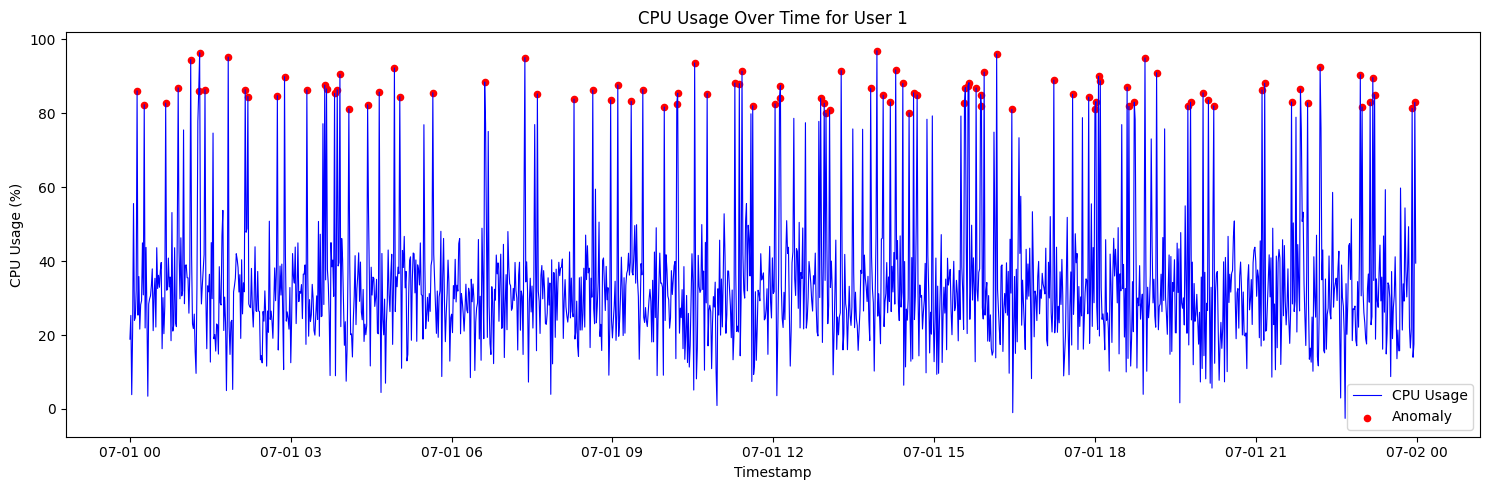

In [10]:
import matplotlib.pyplot as plt

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Filter data for one user
user_data = df[df['User_ID'] == 'user_1'].sort_values('Timestamp')

# Plot CPU usage with anomalies highlighted
plt.figure(figsize=(15, 5))
plt.plot(user_data['Timestamp'], user_data['CPU_Usage'], label='CPU Usage', color='blue', linewidth=0.8)
anomalies = user_data[user_data['Anomaly_Label'] == 1]
plt.scatter(anomalies['Timestamp'], anomalies['CPU_Usage'], color='red', label='Anomaly', s=20)
plt.xlabel('Timestamp')
plt.ylabel('CPU Usage (%)')
plt.title('CPU Usage Over Time for User 1')
plt.legend()
plt.tight_layout()
plt.show()

### **Outcome**
- Normal CPU usage for this user fluctuates mostly between 0 and 50 percent throughout the day
- Almost all anomalies occur during high spikes, roughly between 80 and 96 percent CPU usage
- Anomalies appear frequently and consistently throughout the entire day, not concentrated in one time period
- This suggests CPU spikes above a certain threshold are a strong indicator of anomalous behavior

## **Step 8: Compare Feature Distributions for Normal vs Anomalous Records**
Here we compare the average values of CPU_Usage, Memory_Usage, Disk_IO, and Network_IO between normal and anomalous records to identify which features are most affected during anomalies.

In [11]:
# Compare mean values of features for normal vs anomalous records
comparison = df.groupby('Anomaly_Label')[['CPU_Usage', 'Memory_Usage', 'Disk_IO', 'Network_IO']].mean()
comparison

,CPU_Usage,Memory_Usage,Disk_IO,Network_IO
Anomaly_Label,,,,
0,30.705891,44.551875,12.859566,8.275428
1,86.293453,39.986030,9.870907,5.045951


### **Outcome**
- Average CPU usage jumps from about 31 percent in normal records to 86 percent in anomalous records, a massive difference
- Memory_Usage is slightly lower during anomalies, about 40 percent versus 44.5 percent normally, but the difference is small
- Disk_IO and Network_IO are both slightly lower during anomalies compared to normal records
- This strongly suggests CPU_Usage is the primary driver of anomalies in this dataset, while other metrics play a minor role

## **Step 9: Anomaly Distribution by Workload Type**
Here we check how anomalies are distributed across different workload types to see if certain workloads are more prone to anomalies than others.

In [12]:
# Anomaly count and rate by workload type
workload_anomaly = df.groupby('Workload_Type')['Anomaly_Label'].agg(['sum', 'count'])
workload_anomaly['anomaly_rate_percent'] = (workload_anomaly['sum'] / workload_anomaly['count']) * 100
workload_anomaly

,sum,count,anomaly_rate_percent
Workload_Type,,,
Backup,0,1457,0.00000
Crypto_Mining,1257,1466,85.74352
Database_Query,0,4296,0.00000
Video_Streaming,0,2870,0.00000
Web_Service,0,4311,0.00000


### **Outcome**
- Backup, Database_Query, Video_Streaming, and Web_Service workloads have zero anomalies
- Crypto_Mining is the only workload type with anomalies, and 85.7 percent of its records are labeled as anomalous
- This means workload type alone is a very strong predictor of anomalies in this dataset
- Combined with the earlier finding on CPU_Usage, this suggests Crypto_Mining workloads cause sustained high CPU usage, which is flagged as anomalous behavior

## **Step 10: Visualize CPU Usage Distribution by Workload Type**
Here we use a boxplot to compare CPU usage distributions across all workload types, which will visually confirm why Crypto_Mining stands out.

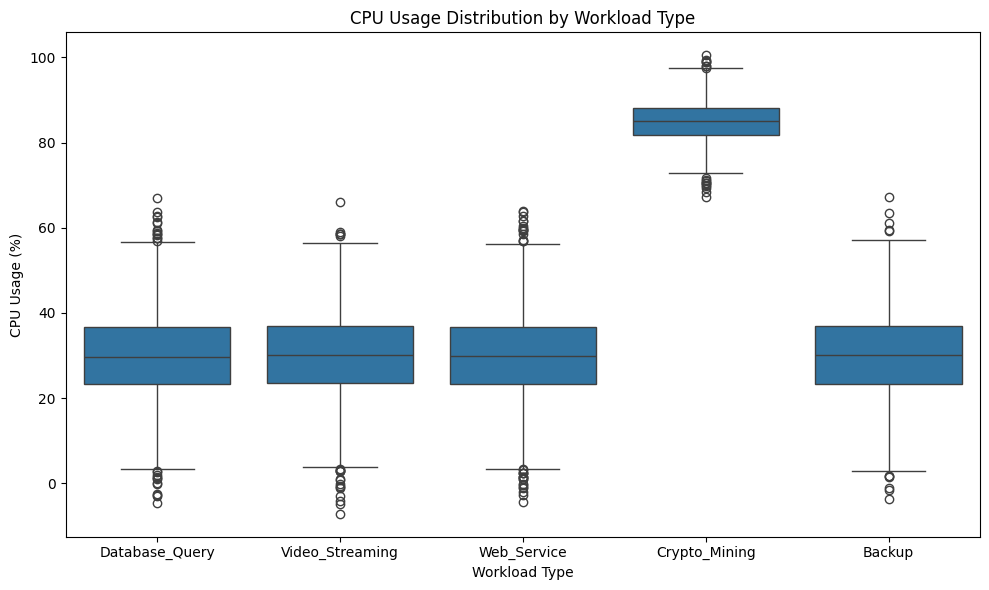

In [13]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Workload_Type', y='CPU_Usage')
plt.title('CPU Usage Distribution by Workload Type')
plt.xlabel('Workload Type')
plt.ylabel('CPU Usage (%)')
plt.tight_layout()
plt.show()

### **Outcome**
- Database_Query, Video_Streaming, Web_Service, and Backup all show a similar CPU usage distribution, mostly between 20 and 40 percent with some outliers
- Crypto_Mining stands completely apart, with CPU usage concentrated between 70 and 100 percent
- There is no overlap between Crypto_Mining and the other workload types, making it a clearly separable pattern
- This confirms that Crypto_Mining workloads are fundamentally different in behavior and are the main source of anomalies in this dataset

## **Step 11: Correlation Between Numeric Features**
Here we examine the correlation between CPU_Usage, Memory_Usage, Disk_IO, Network_IO, and Anomaly_Label to understand which features are most related to anomalies.

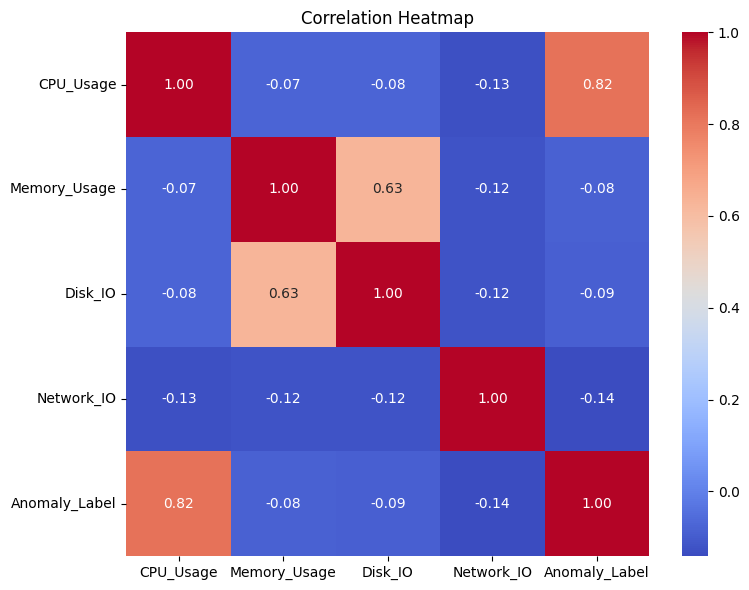

In [14]:
# Correlation matrix
plt.figure(figsize=(8, 6))
correlation_matrix = df[['CPU_Usage', 'Memory_Usage', 'Disk_IO', 'Network_IO', 'Anomaly_Label']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### **Outcome**
- CPU_Usage has a very strong correlation of 0.82 with Anomaly_Label, confirming it is the dominant factor behind anomalies
- Memory_Usage and Disk_IO have a moderate positive correlation of 0.63 with each other, but both have very weak correlation with anomalies
- Network_IO has a weak negative correlation of -0.14 with anomalies, meaning it plays little role
- Overall, CPU_Usage is by far the most important feature for detecting anomalies in this dataset

## **Step 12: Prepare Data for Modeling**
Here we select relevant features, encode categorical variables, and split the data into training and testing sets.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode Workload_Type as numeric
le = LabelEncoder()
df['Workload_Type_Encoded'] = le.fit_transform(df['Workload_Type'])

# Select features and target
features = ['CPU_Usage', 'Memory_Usage', 'Disk_IO', 'Network_IO', 'Workload_Type_Encoded']
X = df[features]
y = df['Anomaly_Label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (11520, 5)
Testing set shape: (2880, 5)


### **Outcome**
- The training set contains 11520 records and the testing set contains 2880 records
- The 80-20 split was stratified, meaning both sets maintain the same proportion of normal and anomalous records as the original dataset

## **Step 13: Train a Random Forest Classifier**
Here we train a Random Forest model to classify records as normal or anomalous based on the selected features.

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


## **Step 14: Evaluate Model Performance**
Here we evaluate the trained model on the test set using accuracy, precision, recall, and F1-score to understand how well it detects anomalies.

In [17]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Make predictions
y_pred = model.predict(X_test)

# Print accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2629
           1       1.00      1.00      1.00       251

    accuracy                           1.00      2880
   macro avg       1.00      1.00      1.00      2880
weighted avg       1.00      1.00      1.00      2880



### **Outcome**
- The model achieved 100 percent accuracy on the test set
- Both normal and anomalous records were classified with perfect precision, recall, and f1-score
- This perfect performance is expected because earlier analysis showed anomalies are almost entirely tied to Crypto_Mining workload combined with very high CPU usage, making the two classes highly separable
- In a real-world scenario with less clear-cut patterns, accuracy this high would be unusual and worth double-checking, but here it aligns with what we already observed in the data

## **Step 15: Visualize Confusion Matrix**
Here we plot the confusion matrix to visually confirm how well the model separates normal and anomalous records.

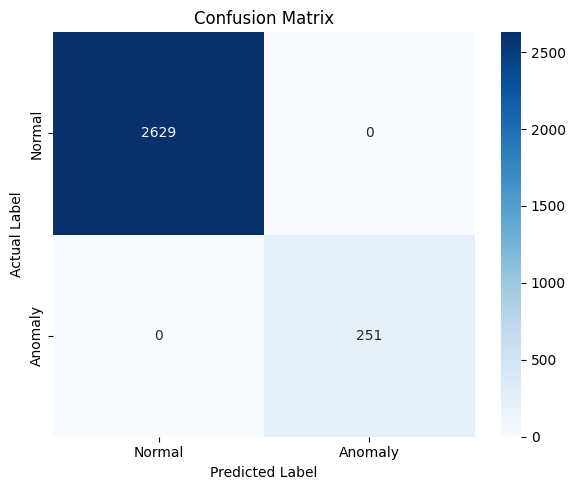

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### **Outcome**
- All 2629 normal records were correctly predicted as normal, with zero false positives
- All 251 anomalous records were correctly predicted as anomalies, with zero false negatives
- The model made no mistakes on the test set, confirming a completely clean separation between the two classes

## **Step 16: Feature Importance**
Here we examine which features the model relied on most to make its predictions.

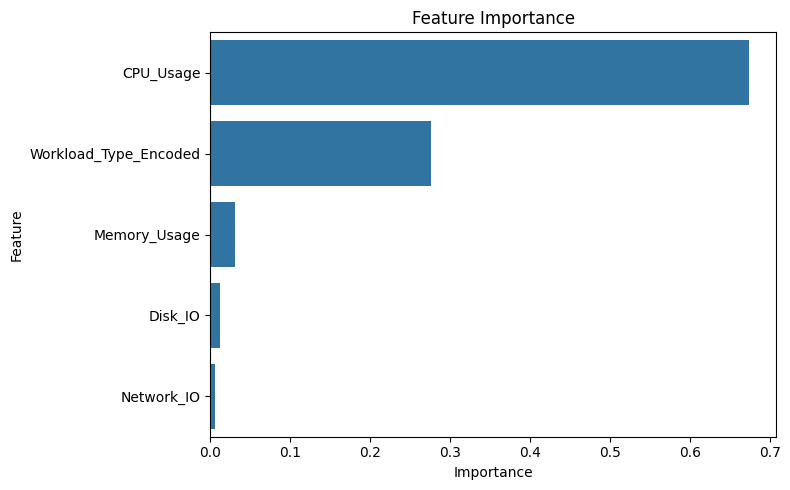

,Feature,Importance
0,CPU_Usage,0.674689
4,Workload_Type_Encoded,0.275802
1,Memory_Usage,0.030926
2,Disk_IO,0.012513
3,Network_IO,0.006070


In [19]:
# Feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

importance

### **Outcome**
- CPU_Usage is the most important feature, contributing about 67 percent of the model decision
- Workload_Type_Encoded is the second most important feature, contributing about 28 percent
- Together, CPU_Usage and Workload_Type account for over 95 percent of the model's decision-making
- Memory_Usage, Disk_IO, and Network_IO contribute very little, confirming what was observed earlier in the correlation analysis and boxplots
- This validates that the model has learned the same pattern we identified through manual analysis, rather than relying on noise or irrelevant features

## **Project Summary**

This project analyzed a cloud resource usage dataset containing 14400 minute-level records across five workload types and ten users, with the goal of detecting anomalous resource usage patterns.

Exploratory analysis revealed that anomalies in this dataset are almost entirely associated with the Crypto_Mining workload type, which showed sustained CPU usage between 70 and 100 percent, clearly separate from the 20 to 50 percent range seen in all other workload types. Other metrics such as Memory_Usage, Disk_IO, and Network_IO showed minimal difference between normal and anomalous records.

A Random Forest classifier was trained using CPU_Usage, Memory_Usage, Disk_IO, Network_IO, and Workload_Type as features. The model achieved 100 percent accuracy, precision, recall, and f1-score on the test set, with zero misclassifications. Feature importance analysis confirmed that CPU_Usage and Workload_Type together accounted for over 95 percent of the model's decision-making, aligning with the patterns identified during exploratory analysis.

This project demonstrates a complete workflow for cloud resource anomaly detection, including data exploration, statistical analysis, visualization, and machine learning model development, using tools and techniques applicable to real-world cloud infrastructure monitoring.